**N2_angular_positions:** Uses the satellite TLE's and the telescope beam model, and calculates the satellites' beam response.

### 1. Initialization

Making the necessary imports.

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.tle_mapping as tle
import satellite_RFI.src.beam_model as bm
import sys
sys.path.insert(0, './initialization/')
from imports import *
import parameters_1554156377 as pm
from skyfield.api import load
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection


In [7]:
# ------------------ parameters -------------------- #
folder_TLEs = "simulation_data/TLE/2019_03_25_tle/"
path_nearby = f"{pm.folder}nearby_{pm.block}.pkl"
path_beam = "{}satbeams_{}_{}_{}-{}.pkl".format(pm.folder, pm.block, pm.beam_model, *pm.freq_range)


In [8]:
# printing quantities that we will probe
_ = tle.get_date(unix=pm.block, verbose=True)
print("Using TLEs from date:",folder_TLEs.split("/")[2][:-4])


Date of observation: 2019-04-02 00:06:17
File name: 1554156377
Using TLEs from date: 2019_03_25


### 2. Downloading TLEs and formatting correctly

#### A. Steps to download TLEs for the present day

We begin by downloading today's TLEs and saving them in the specified path. The steps for renaming the satellite names in the files were also performed for the observation TLEs once, with a slightly modified function.

In [36]:
# downloading TLEs from celestrak for the present date
#path = tle.download_TLEs(path_folder,verbose=True)


Writing over existing folder

In [29]:
# editing files
tle.clean_satnames(folder_TLEs,verbose=True)
tle.extract_QIs(folder_TLEs,verbose=True)


#### B. Extracting satellite names for satellite catalog

Celestrak changes naming conventions throughout time; as such, it's better to just employ the naming conventions that it used at the time of the observation, and just extract those names based on NORAD ID to the satellite catalog.

In [6]:
# if we are repeating this, we need to remove the column first
#satellites = pd.read_csv(pm.folder + "satellites.csv")
#satellites.drop(columns=[f"Name {pm.block}"], inplace=True)
#satellites.to_csv(pm.folder + "satellites.csv", index=False)


In [9]:
# getting catalog
satellites = pd.read_csv(pm.folder + "satellites.csv")
satellites.set_index("NORAD ID", inplace=True)
satellites.insert(0, f"Name {pm.block}", "")

# getting info from TLEs
cons = ["gps-ops","glo-ops","galileo","beidou","irnss","qzs","sbas"]
for con in cons:
    data = load.tle_file(folder_TLEs + con + ".txt")
    for sat in data:  
        satellites.loc[sat.model.satnum,f"Name {pm.block}"] = sat.name


In [10]:
# saving catalog
satellites.to_csv(pm.folder + "satellites.csv", index=True)


### 3. Determining angular positions

#### A. Creating object

The calculations of the satellites' angular positions in the sky will be all calculated and saved within the `SatBeamCalculator` object, defined in *tle_mapping.py* (previously in *check_satellite.py*). I'm experimenting and will try to change the indexing from the satellite names (requires precise formatting, names change throughout time) to NORAD IDs (immutable, easy to index).

Comparing with the previous angular maps, we've managed to get rid of all satellites that had weird maps and had been incorrectly kept previously. There were also 2 additional satellites that were previously not being considered, and these were found to be further than 100deg or below the horizon for all of the observation and so they weren't kept and don't alter the simulations!


In [11]:
# getting the date from the block
max_angle = 100

# initializing the satbeam calculator
sm = tle.SatelliteMap(
    path_TLEs=folder_TLEs, 
    t_start = pm.block + pm.nd_s0[0], 
    times = pm.nd_s0, 
    location = [pm.TL_latitude, pm.TL_longitude], 
    pointings = np.array(pm.nd_s0_coords).T, 
    max_angle = max_angle, 
    verbose = True
)


Extracting TLEs...
Setting time and location...
Getting coordinates and angular separations...
Number of satellites: 14 (gps-ops), 11 (glo-ops), 9 (galileo), 10 (beidou), 5 (irnss), 6 (sbas), 

#### B. Checking some plots

From this object we can already see that BEIDOU 3 M1 that is selected is 43001, and that indeed only one of the satellites appears (the other wasn't written over).

We can already compare some properties with previous results; for example, we had several weird smooth beam response plots, and those require a very smooth trajectory for that satellite.

**Comparison between satellite trajectories and final beam response map:** 
- *GPS-BIIF-9:* Lacks mask.
- *GPS-BIIR-8:* Weird feature halfway.
- *GPS-BIIRM-2:* Weird declining trend, and lacks mask.
- *GPS-BIIRM-6:* Weird small upward trend.
- *GPS-BIIR-9:* Should not be in the list! = Smooth plot.
- *GSAT 209:* Check with a more agreeable plot, should be fine and only has a weird plot because it comes very close to the telescope.
- *GSAT 210:* Should not be in the list! = Smooth plot.
- *GSAT 203:* Should not be in the list! = Smooth plot.
- *GSAT 214:* Weird feature in the beggining.
- *GSAT 102:* Weird feature in the beginning.
- *GSAT 218:* Weird peak.
- *IRNSS 1C:* Lacks mask.
- *SBAS-GSAT 15:* Should not be in the list! = Smooth plot.
- *SBAS-LUCH 5V:* Should not be in the list! = Smooth plot.
- *SBAS-GSAT 10:* Lacks mask.
- *COSMOS 2516:* Appears to increase.
- *COSMOS 2492:* Should not be in the list! = Smooth plot.
- *COSMOS 2426:* Weird peak at the end.
- *COSMOS 2464:* Should not be in the list! = Smooth plot.
- *COSMOS 2433:* Lacks mask.
- *COSMOS 2432:* Weird peaks at the beginning.
- *COSMOS 2477:* Check with a more agreeable plot, should be fine and only has a weird plot because it comes very close to the telescope.
- *BEIDOU I1-S:* Should not be in the list! = Smooth plot.
- *BEIDOU IGSO-6:* Should not be in the list! = Smooth plot.
- *BEIDOU IGSO-5:* Should not be in the list! = Smooth plot.
- *BEIDOU I2-S:* Should not be in the list! = Smooth plot.
- *BEIDOU M6:* Weird peaks at the beginning.
- *BEIDOU IGSO-6:* Should not be in the list! = Smooth plot.
- *BEIDOU 3-M7*: Weird peaks at the end and lacks mask.
- *BEIDOU G6:* Should not be in the list! = Smooth plot.
- *BEIDOU G3:* Lacks mask.
- *BEIDOU 3 M8:* Should not be in the list! = Smooth plot.

Weird features specifically can be mostly due to the telescope beam having a sinusoidal-like behavior, and so despite going farther out they cross a peak where the emission is higher than when they were closer.

In [12]:
# ------------------ plot_polar ----------------- #
def plot_polar(sm):
    ''' Makes a polar plot of the satellite tracks and telescope
    pointing in the southern hemisphere. '''

    # creating figure
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="polar", theta_offset=0.5 * np.pi, theta_direction=-1)
    colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
              "#8c564b","#e377c2","#17becf","#bcbd22","#7f7f7f"]
    legends = []
    
    for i,con in enumerate(sm.cons):

        # plotting telescope pointing
        ax.plot(np.deg2rad(sm.pointings[:, 0]), 90-sm.pointings[:, 1],
                alpha=1, color="#808080", label="Coverage")

        # plotting satellite tracks
        for coords_sat in sm.coords[i]:
            ax.plot(np.deg2rad(coords_sat[:,0]), 90 - coords_sat[:,1], ".-",
                    color=colors[i], mfc=colors[i], mec="none", lw=0.1, ms=2)
        legends.append(mpatches.Patch(color=colors[i], label=con))

    # showing figure
    legends.append(mpatches.Patch(color="#808080", label="Coverage"))
    ax.set_rlim(0, 90)
    ax.set_title("Polar plot of satellites")
    ax.legend(handles=legends, frameon=False, markerfirst=False,
              loc=1, bbox_to_anchor=(1,0.1,0.15,1) )
    plt.show()
    return


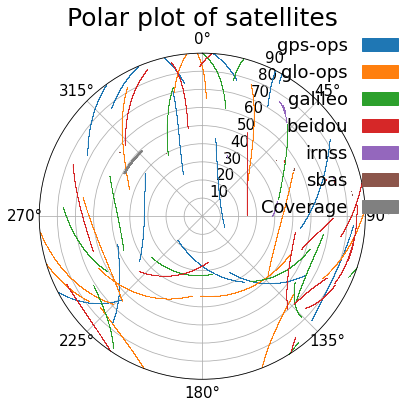

In [13]:
# plotting the trajectory calculations
plot_polar(sm)


In [14]:
# -------------- plot_under_limit --------------- #
def plot_under_limit(sm, limit=5, constellation=None):
    ''' Plots satellites that go within the angle limit at least once. '''
    
    # creating figure
    fig, ax = plt.subplots(figsize=(16, 8))
    linestyles = ["-", "--", "-.", ":"]
    dtimes = (sm.t_start + sm.times).datetime

    # select satellites under limit at least once and plot
    for i,con in enumerate(sm.cons):
        if (constellation is not None) and (con!=constellation):  continue
        under_limit = np.any(sm.angseps[i] < limit, axis=1)
        for j,ID in enumerate(sm.sats[i].keys()):
            if under_limit[j]:
                angles = sm.angseps[i][j]
                name = sm.sats[i][ID].name
                ax.plot(sm.times.value, angles, linestyle=linestyles[j%4], 
                        label=f"{name}")
                #ax.plot(angles, linestyle=linestyles[j%4], 
                #        label=f"{name}")

    # showing figure
    ax.axhline(limit, color="black", ls="--")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Angular separation [deg]")
    idx = np.linspace(0, len(dtimes) - 1, 20, dtype=int)
    ax.set_xticks(sm.times.value[idx])
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(sm.times.value[idx])
    ax2.set_xticklabels([t.strftime("%H:%M:%S") for t in dtimes[idx]], rotation=45)
    ax2.set_xlabel("UTC")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return


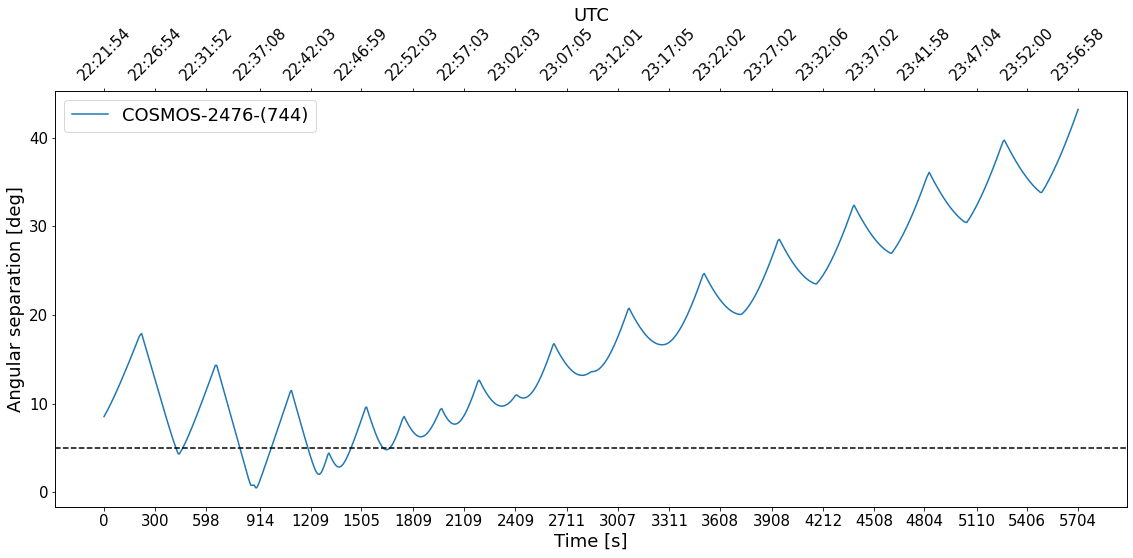

In [15]:
# plotting the satellites under the defined limit
plot_under_limit(sm, limit=5)


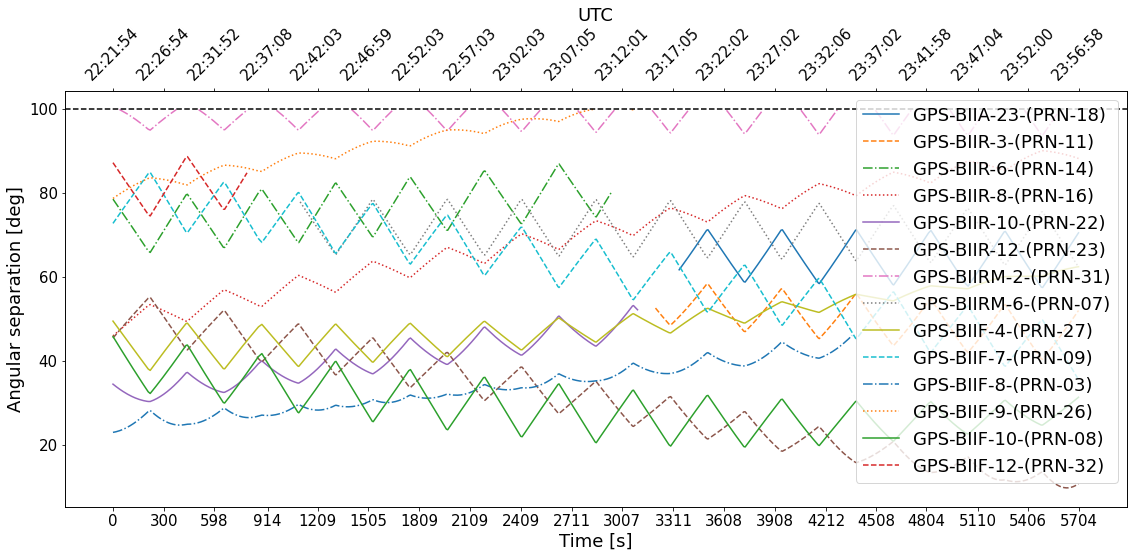

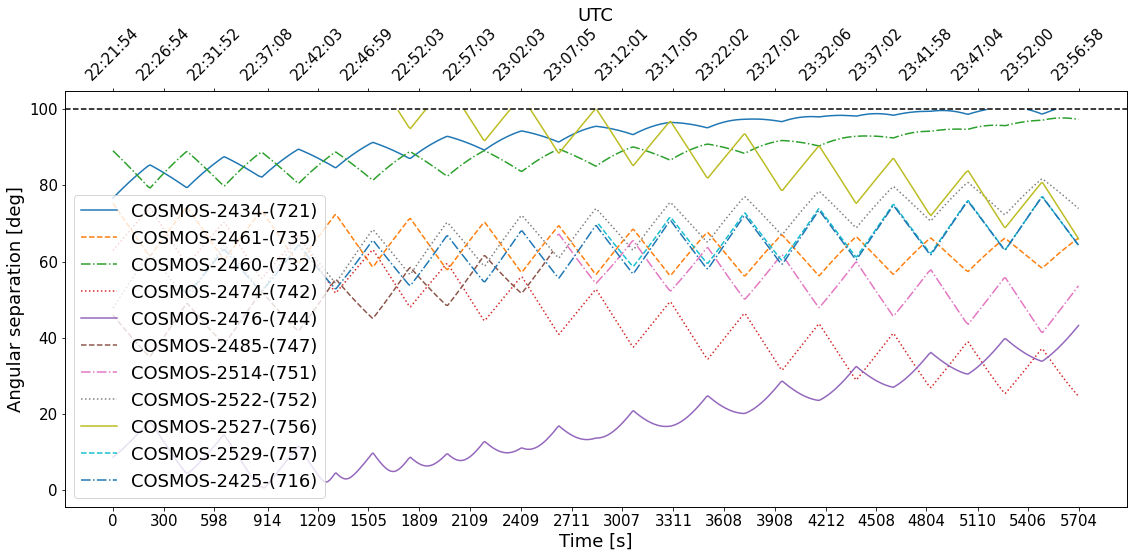

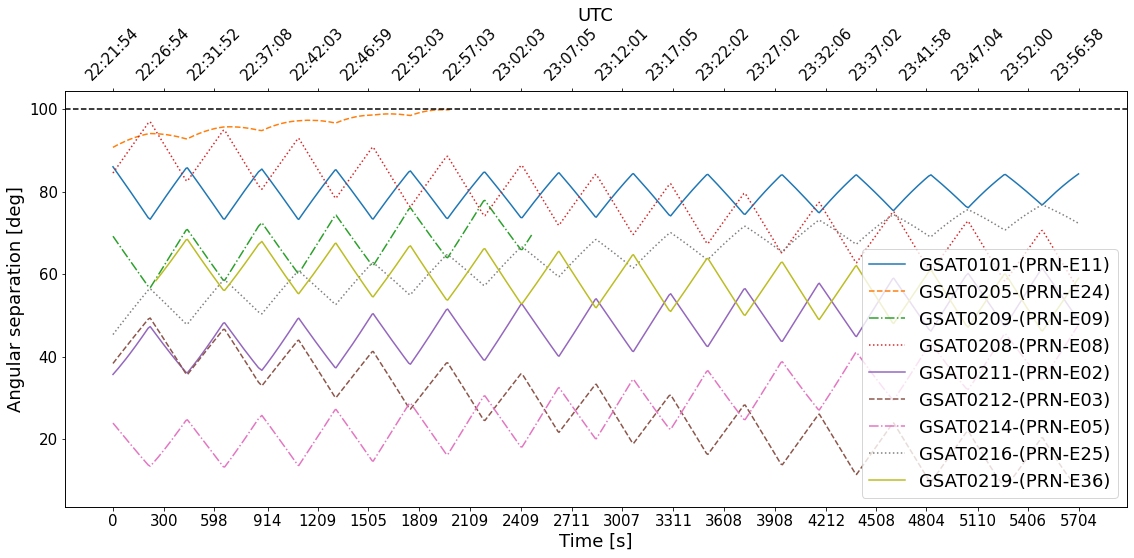

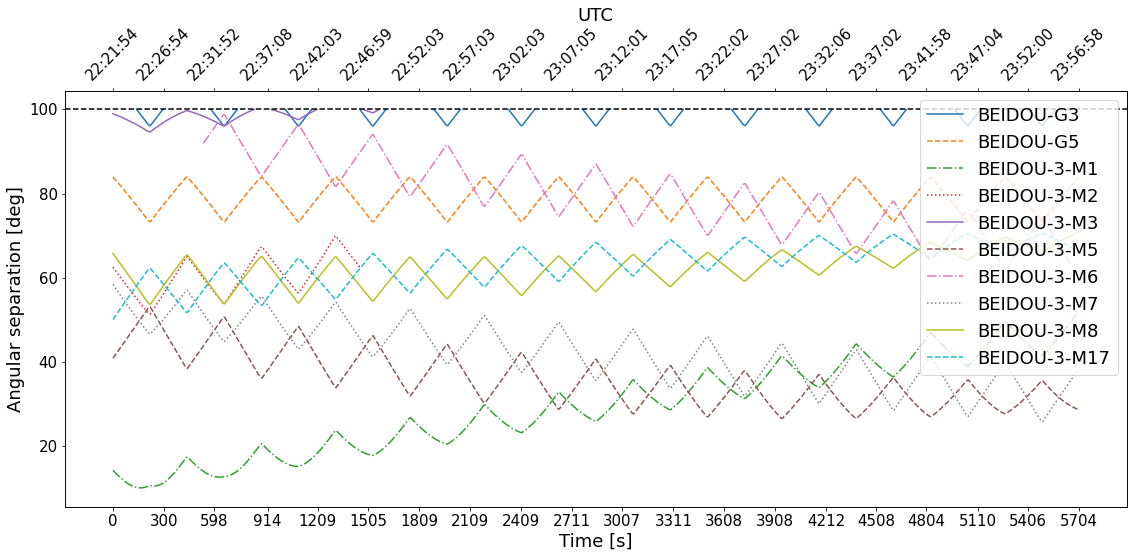

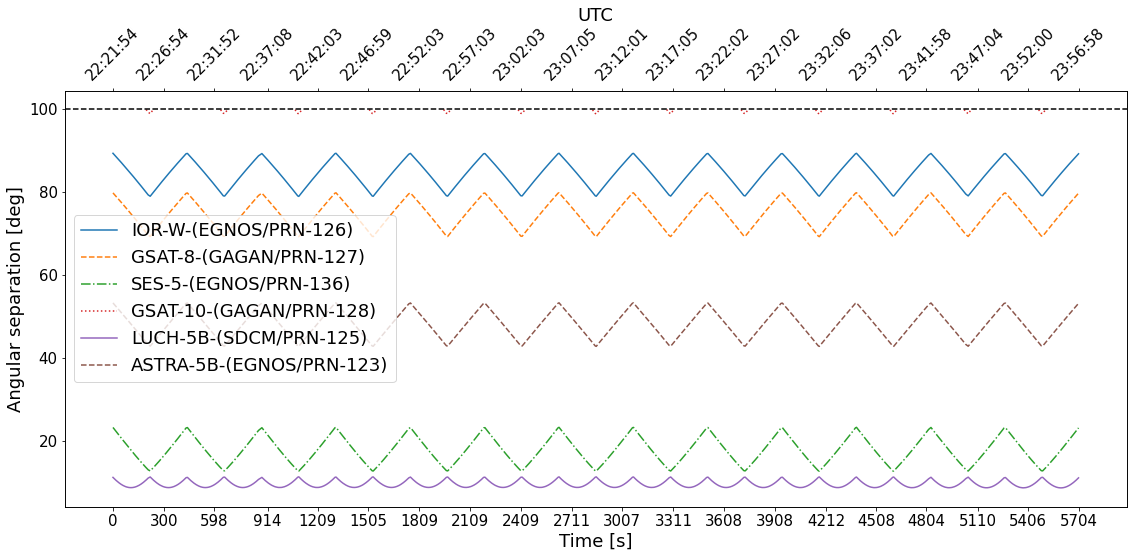

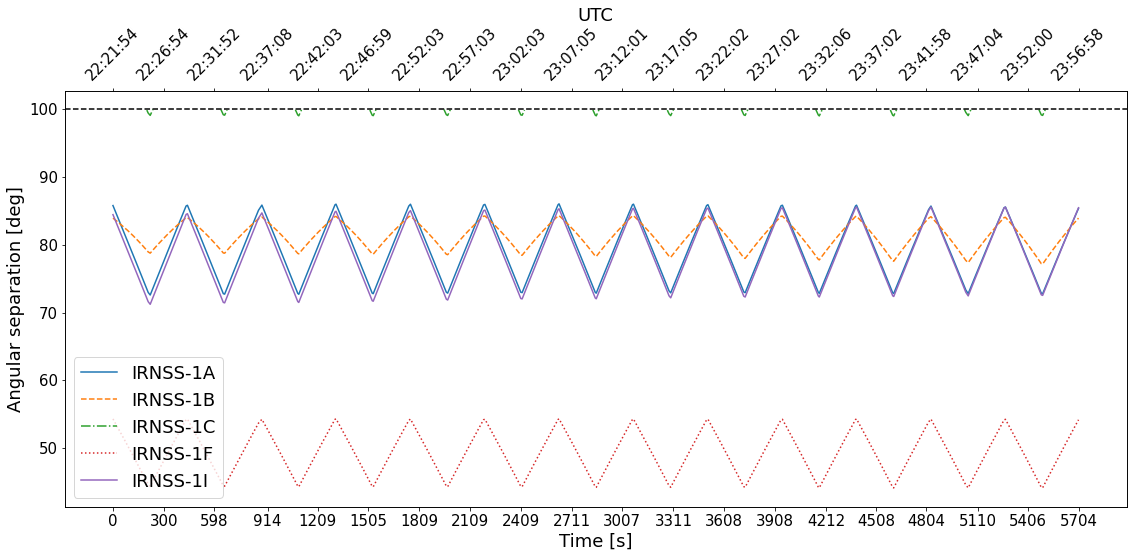

In [16]:
# plotting all satellites
cons = ["gps-ops","glo-ops","galileo","beidou","sbas","irnss"]
for con in cons:
    plot_under_limit(sm, limit=max_angle, constellation=con)


In [17]:
# --------------- plot_pointings ---------------- #
def plot_pointings(sm, Ni=None, Nf=None):
    ''' Plot graphs of telescope pointing. '''

    # First figure - creating figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    az = sm.pointings[Ni:Nf, 0]
    alt = sm.pointings[Ni:Nf, 1]

    # az,alt plotting
    ax1.plot(sm.times.value[Ni:Nf], az)
    ax1.set_ylabel("Azimuth [deg]")
    ax2.plot(sm.times.value[Ni:Nf], alt)
    ax2.set_ylabel("Altitude [deg]")
    ax2.set_xlabel("Time [s]")

    # showing figure
    ax1.ticklabel_format(style="plain", axis="both", useOffset=False)
    ax2.ticklabel_format(style="plain", axis="both", useOffset=False)
    plt.tight_layout()
    plt.show()

    # Second figure - creating figure and plotting
    points = np.column_stack((az, alt)).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="viridis")
    if Nf is None:  lc.set_array(sm.times.value[Ni:-1])
    else:  lc.set_array(sm.times.value[Ni:Nf-1])
    lc.set_linewidth(2)

    # showing figure
    fig, ax = plt.subplots()
    ax.add_collection(lc)
    ax.autoscale()
    ax.ticklabel_format(style="plain", axis="both", useOffset=False)
    plt.colorbar(lc, label="Sample index")
    plt.show()
    

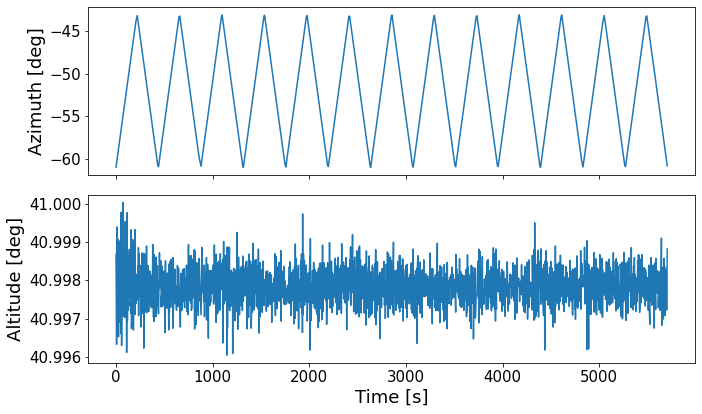

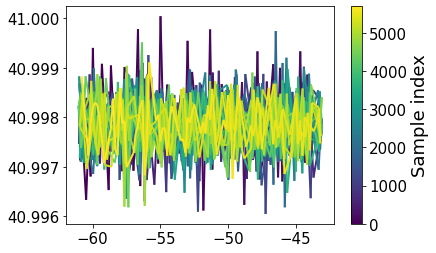

In [18]:
# plotting satellite pointing
plot_pointings(sm, Ni=None, Nf=None)


In [19]:
# --------- plot_pointings_under_limit ---------- #
def plot_pointings_under_limit(sm, limit=5):
    """Plot the telescope RA/Dec track, highlighting times 
    when satellites are within 'limit' degrees."""

    # plotting pointings RA,DEC
    RA = pm.nd_s0_coords2[0]
    DEC = pm.nd_s0_coords2[1]
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(RA, DEC, "--", color="k", label="Pointing")

    # replot pointings with satellites within the limit
    for i,con in enumerate(sm.cons):
        for j,ID in enumerate(sm.sats[i].keys()):
            angles = sm.angseps[i][j]
            idx = np.where((angles<limit) & (~angles.mask))[0]
            if len(idx): 
                ax.plot(RA[idx], DEC[idx], ".", label=f"{con}: {sm.sats[i][ID].name}")

    # showing figure
    ax.set_xlabel("RA [deg]")
    ax.set_ylabel("Dec [deg]")
    ax.legend(frameon=True, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()
    

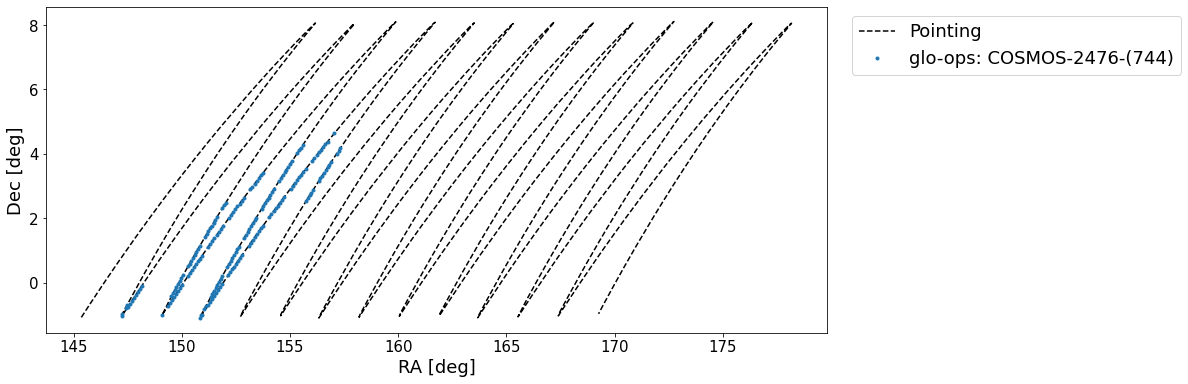

In [20]:
# highlighting pointings with satellites under limit
plot_pointings_under_limit(sm, limit=5)


#### C. Getting nearby satellites

Created a function in *tle_mapping.py* which checks the satellites that cross below the angle threshold given.

In [22]:
# getting indexes where satellites pass nearby and saving
angles = np.array([1,5])
print(f"Checking angles {angles}...")
data = sm.get_nearby_sats(angles, verbose=True)
pickle.dump(data,open(path_nearby,'wb'))


Checking angles [1 5]...
Checking angle 1...
	Found satellite COSMOS-2476-(744) (37867) from glo-ops!
Checking angle 5...
	Found satellite COSMOS-2476-(744) (37867) from glo-ops!


#### D. Getting satellite telescope beam

We start by defining the necessary functions; as we only have EMSS defined in a specific frequency x theta grid, we interpolate to the desired points using `RectBivariateSpline`.

In [23]:
# getting interpolator
_interp = bm.EMSS_interpolator()
freqs = pm.frequency[(pm.frequency>=pm.freq_range[0]) & (pm.frequency<=pm.freq_range[1])]

# defining beam model
def EMSS(frequency,theta):
    ''' Final EMSS beam with frequency pre-defined. '''
    return bm.EMSS(frequency, theta, _interp)


In [24]:
# calculating satbeam
start = time.perf_counter()
print("Calculating satbeam")
sm.get_satbeam(freqs,EMSS,verbose=True)
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Calculating satbeam
	Getting gps-ops...
	Getting glo-ops...
	Getting galileo...
	Getting beidou...
	Getting irnss...
	Getting sbas...
This took 179.09 seconds, or 2.98 minutes


In [25]:
# saving data
saved_data = {ID : sm.satbeam[ID].filled(0) for ID in sm.satbeam}
pickle.dump(saved_data,open(path_beam,'wb'))


## 4. Comparing results

#### A. Checking nearby_sats file

We can see from the plots that the old maps were cutting a lot more indexes than necessary, and that the new values are strictly those where there are satellites below the specified degree. In the end, at the very least this means that the angular mask will take a lesser percentage of the overall data. 

In [26]:
# getting old+new files - nearby
print("Getting old files...")
path_old1 = pm.path_data + f"nearby_satellites/nearby_satellite_close_angle_{'1F'}.p"
old1 = pickle.load(open(path_old1, "rb"), encoding="latin1") 
path_old5 = pm.path_data + f"nearby_satellites/nearby_satellite_close_angle_{'5F'}.p"
old5 = pickle.load(open(path_old5, "rb"), encoding="latin1") 
print("Getting new file...")
new = pickle.load(open(path_nearby, "rb")) 


Getting old files...
Getting new file...


In [27]:
# creating a comparable dictionary
cons = ["gps-ops","glo-ops","beidou","galileo","irnss","sbas"]
lista1 = [];  lista5 = []
for c in cons:
    lista1.append(old1[c])
    lista5.append(old5[c])
old = {}
old[1] = np.unique(np.concatenate(lista1))
old[5] = np.unique(np.concatenate(lista5))


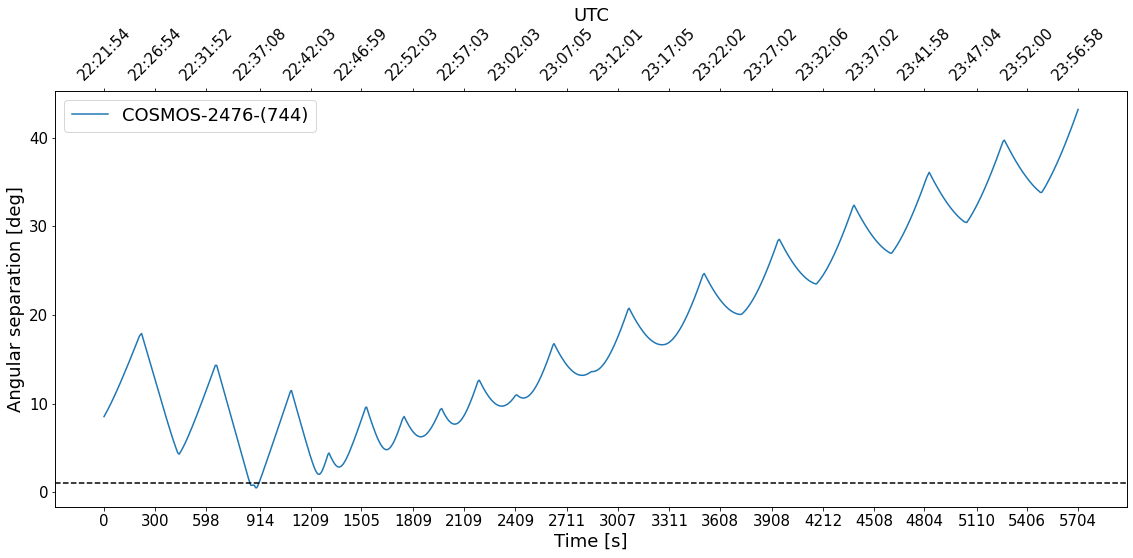

Additional indexes in the old: []
Additional indexes in the new: [329 330 331 337 338 339 340 341]


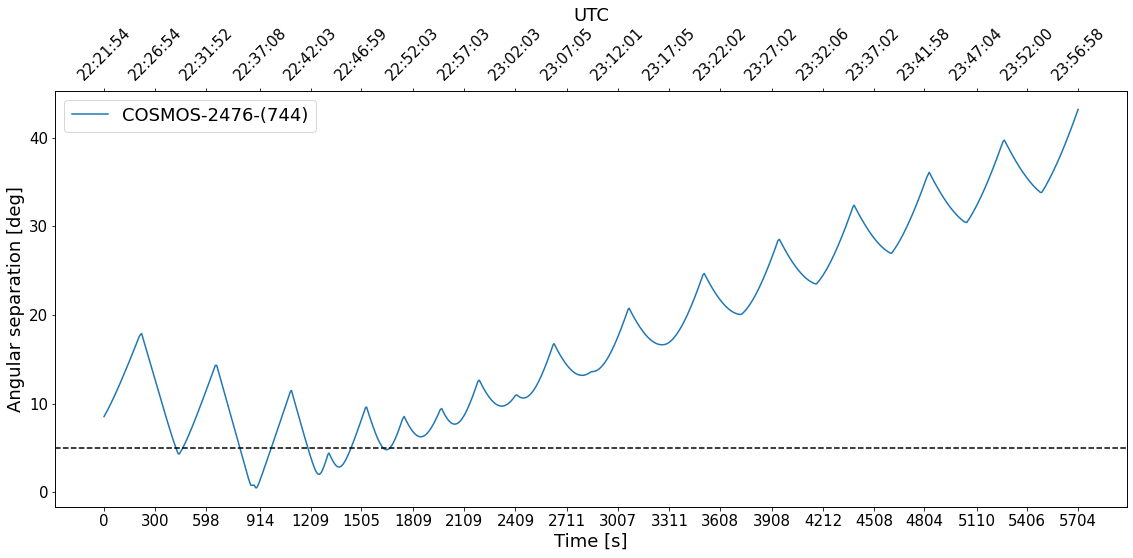

Additional indexes in the old: [176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211
 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265
 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283
 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301
 302 303 304 372 373 374 375 376 377 378 379 380 381 382 383 384 385 386
 387 388 389 390 391 392 393 394 395 396 397 398 399 400 401 402 403 404
 405 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422
 423 424 425 426 427 428 429 430 431 432 433 434 435 436 437 438 439 440
 441 442 443 444 445 446 447 448 449 450 451 452 453 552 553 554 555 556
 557 558 559 560 561 562 563 564 565 566 567 568 569 570 571 572 573 574
 575 576 577 578 579

In [28]:
# checking if the lists are correct
for i in [1,5]:
    plot_under_limit(sm,i)
    print(f"Additional indexes in the old: {np.setdiff1d(old[i], new[i])}")
    print(f"Additional indexes in the new: {np.setdiff1d(new[i], old[i])}")
